# 在同一坐标系可视化 VGGT 与 SAM3D 关键点

这个 Notebook 用 **左相机坐标系** 作为统一坐标系：
- VGGT 的相机位姿先从 VGGT world 坐标变换到左相机坐标。
- SAM3D 的 `pred_keypoints_3d` 默认按左相机坐标直接绘制。
- 若提供右相机 SAM3D 与 `relative_pose_info.npz`，会把右侧关键点变换到左坐标后叠加绘制。

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ---------- 工具函数 ----------
def load_vggt_npz(vggt_npz_path: str):
    d = np.load(vggt_npz_path, allow_pickle=True)
    keys = set(d.files)

    # 格式1: *_vggt_3d_info.npz，直接有 R/t/C
    if {"R", "t", "C", "camera_intrinsics"}.issubset(keys):
        return {
            "R": np.asarray(d["R"], dtype=np.float32),
            "t": np.asarray(d["t"], dtype=np.float32),
            "C": np.asarray(d["C"], dtype=np.float32),
            "K": np.asarray(d["camera_intrinsics"], dtype=np.float32),
        }

    # 格式2: 可能只有 extrinsic/intrinsic
    if {"extrinsic", "intrinsic"}.issubset(keys):
        ext = np.asarray(d["extrinsic"], dtype=np.float32)
        intr = np.asarray(d["intrinsic"], dtype=np.float32)

        # 兼容形状: (N,2,3,4) 或 (2,3,4)
        if ext.ndim == 3:
            ext = ext[None, ...]
        if ext.shape[-2:] == (4, 4):
            ext = ext[..., :3, :]

        R = ext[..., :3, :3]
        t = ext[..., :3, 3]
        C = -np.einsum("...ij,...j->...i", np.swapaxes(R, -1, -2), t)

        if intr.ndim == 3:
            intr = intr[None, ...]

        return {
            "R": R.astype(np.float32),
            "t": t.astype(np.float32),
            "C": C.astype(np.float32),
            "K": intr.astype(np.float32),
        }

    raise KeyError(f"不支持的 VGGT npz 字段: {list(d.files)}")


def load_sam3d_kpt(npz_path: str):
    d = np.load(npz_path, allow_pickle=True)

    if "output" in d.files:
        obj = d["output"]
    elif "outputs" in d.files:
        obj = d["outputs"]
    else:
        raise KeyError(f"SAM3D npz 未找到 output/outputs 字段: {list(d.files)}")

    # 兼容 object 标量包装
    if isinstance(obj, np.ndarray) and obj.ndim == 0:
        obj = obj.item()

    # 如果是按帧数组，取第 0 帧
    if isinstance(obj, np.ndarray) and obj.dtype == object and obj.ndim >= 1:
        obj = obj[0]
        if isinstance(obj, np.ndarray) and obj.ndim == 0:
            obj = obj.item()

    if not isinstance(obj, dict):
        raise TypeError(f"SAM3D output 类型异常: {type(obj)}")

    if "pred_keypoints_3d" not in obj:
        raise KeyError(f"SAM3D output 缺少 pred_keypoints_3d，字段: {list(obj.keys())[:20]}")

    kpt3d = np.asarray(obj["pred_keypoints_3d"], dtype=np.float32)
    if kpt3d.ndim == 3:
        kpt3d = kpt3d[0]  # (N_person, N_joint, 3) -> 取第一个人
    if kpt3d.ndim != 2 or kpt3d.shape[1] != 3:
        raise ValueError(f"pred_keypoints_3d 形状不符合预期: {kpt3d.shape}")

    return kpt3d


def world_to_cam(points_world: np.ndarray, R: np.ndarray, t: np.ndarray):
    """X_cam = R @ X_world + t"""
    return (R @ points_world.T).T + t[None, :]


def apply_right_to_left(left_to_right_R: np.ndarray, left_to_right_t: np.ndarray, points_right: np.ndarray):
    """X_left = R_lr^T @ (X_right - t_lr)"""
    R_rl = left_to_right_R.T
    t_rl = -R_rl @ left_to_right_t
    return (R_rl @ points_right.T).T + t_rl[None, :]

In [5]:
# ---------- 路径与参数（按你的数据修改） ----------
vggt_npz_path = "/workspace/data/vggt_npy/run_3.npz"

# 左侧 SAM3D（必填）
sam3d_left_npz_path = "/workspace/data/sam3d_body_results/person/run_3/osmo_2_sam_3d_body_outputs.npz"

# 右侧 SAM3D（可选，不填就设为 None）
sam3d_right_npz_path = "/workspace/data/sam3d_body_results/person/run_3/osmo_1_sam_3d_body_outputs.npz"

# 如果你有 *_relative_pose_info.npz 可填路径；没有就设为 None（会自动用 VGGT 计算）
relative_pose_npz_path = None

# 选哪一帧
frame_idx = 0

# 可视化点大小
sam_point_size = 18
cam_point_size = 80

VGGT frame=0 baseline (left->right) = 1.444851


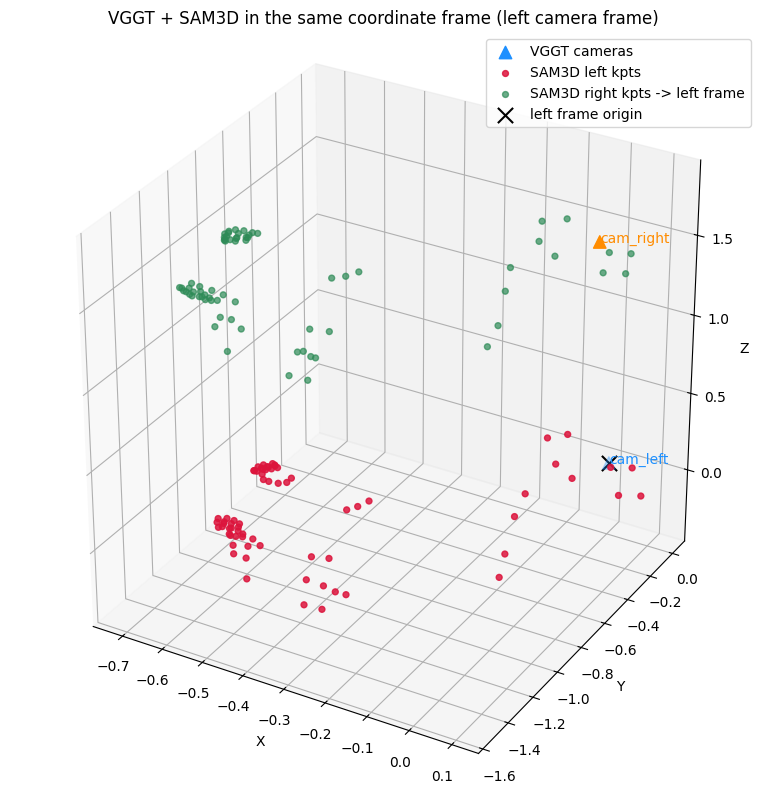

In [6]:
# ---------- 主流程：统一到左相机坐标系并绘图 ----------
# 1) 读取 VGGT
vggt = load_vggt_npz(vggt_npz_path)
R_all = np.asarray(vggt["R"], dtype=np.float32)  # (N,2,3,3)
t_all = np.asarray(vggt["t"], dtype=np.float32)  # (N,2,3)
C_all = np.asarray(vggt["C"], dtype=np.float32)  # (N,2,3)

if frame_idx < 0 or frame_idx >= R_all.shape[0]:
    raise IndexError(f"frame_idx={frame_idx} 越界，合法范围: [0, {R_all.shape[0]-1}]")

# 当前帧两相机外参（world->cam）
R0, t0 = R_all[frame_idx, 0], t_all[frame_idx, 0]
R1, t1 = R_all[frame_idx, 1], t_all[frame_idx, 1]

# 将 VGGT world 下的两个相机中心变换到左相机坐标系
C_world = C_all[frame_idx]                     # (2,3)
C_left_frame = world_to_cam(C_world, R0, t0)  # (2,3)

# 2) 读取 SAM3D 左侧关键点（默认其坐标就在左相机坐标系）
kpt_left = load_sam3d_kpt(sam3d_left_npz_path)

# 3) 可选：读取 SAM3D 右侧关键点并变换到左坐标系
kpt_right_as_left = None
if sam3d_right_npz_path is not None:
    kpt_right = load_sam3d_kpt(sam3d_right_npz_path)

    # 先算 VGGT 的 left->right 相对位姿（作为默认）
    rel_R = R1 @ R0.T
    rel_t = t1 - rel_R @ t0

    # 若提供 relative_pose 文件，则优先覆盖
    if relative_pose_npz_path is not None and Path(relative_pose_npz_path).exists():
        rel_data = np.load(relative_pose_npz_path, allow_pickle=True)
        if "relative_R" in rel_data.files and "relative_t" in rel_data.files:
            rr = np.asarray(rel_data["relative_R"], dtype=np.float32)
            rt = np.asarray(rel_data["relative_t"], dtype=np.float32)
            rel_idx = min(frame_idx, rr.shape[0] - 1)
            rel_R, rel_t = rr[rel_idx], rt[rel_idx]
        else:
            print("[WARN] relative_pose_npz 没有 relative_R/relative_t，继续使用 VGGT 相对位姿")

    # 把右侧关键点变换到左坐标系
    kpt_right_as_left = apply_right_to_left(rel_R, rel_t, kpt_right)

# 4) baseline 信息检查
rel_R_vggt = R1 @ R0.T
rel_t_vggt = t1 - rel_R_vggt @ t0
baseline = float(np.linalg.norm(rel_t_vggt))
print(f"VGGT frame={frame_idx} baseline (left->right) = {baseline:.6f}")

# 5) 绘图
fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection="3d")

# 相机中心
ax.scatter(
    C_left_frame[:, 0],
    C_left_frame[:, 1],
    C_left_frame[:, 2],
    s=cam_point_size,
    c=["dodgerblue", "darkorange"],
    marker="^",
    label="VGGT cameras",
)
ax.text(C_left_frame[0, 0], C_left_frame[0, 1], C_left_frame[0, 2], "cam_left", color="dodgerblue")
ax.text(C_left_frame[1, 0], C_left_frame[1, 1], C_left_frame[1, 2], "cam_right", color="darkorange")

# SAM 左侧关键点
ax.scatter(
    kpt_left[:, 0],
    kpt_left[:, 1],
    kpt_left[:, 2],
    s=sam_point_size,
    c="crimson",
    alpha=0.85,
    label="SAM3D left kpts",
)

# SAM 右侧关键点（如果可用）
if kpt_right_as_left is not None:
    ax.scatter(
        kpt_right_as_left[:, 0],
        kpt_right_as_left[:, 1],
        kpt_right_as_left[:, 2],
        s=sam_point_size,
        c="seagreen",
        alpha=0.7,
        label="SAM3D right kpts -> left frame",
    )

# 在原点画一个小十字，表示左相机坐标系原点
origin = np.zeros((1, 3), dtype=np.float32)
ax.scatter(origin[:, 0], origin[:, 1], origin[:, 2], s=120, c="black", marker="x", label="left frame origin")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("VGGT + SAM3D in the same coordinate frame (left camera frame)")
ax.legend(loc="best")
ax.set_box_aspect([1, 1, 1])
plt.tight_layout()
plt.show()